In [1]:
import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler, MissingValuesFiller
from darts.models import TSMixerModel

# 1. 데이터 로드
df = pd.read_csv('../data/processed/smart_meter_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# [Perplexity 제안 1] 통계 기반 클리핑 (음수 제거 및 상위 1% 이상치 억제)
# 유량(Flow_Instant)과 수압(Pressure) 모두에 적용
for col in ['Flow_Instant', 'Pressure']:
    upper_limit = df[col].quantile(0.99) # 상위 1% 값 계산
    df[col] = df[col].clip(lower=0, upper=upper_limit)

# [Perplexity 제안 2] 30분 단위 리샘플링 (피크 타임 보존)
df_resampled = df.set_index('Timestamp').resample('30T').mean().reset_index()

# 2. Darts 객체 생성 및 결측치 채우기
series = TimeSeries.from_dataframe(df_resampled, 'Timestamp', ['Flow_Instant', 'Pressure'])
filler = MissingValuesFiller() # 짧은 결측치는 기본 보간으로 처리
series_filled = filler.transform(series)

# 3. 스케일링 (0~1 정규화)
scaler = Scaler()
series_scaled = scaler.fit_transform(series_filled)

# 4. 데이터 분할 (30분 단위이므로 7일은 336개 시점 = 48개/일 * 7일)
# 학습 데이터는 2025-03-20 이전까지 사용
train, val = series_scaled.split_before(pd.Timestamp('2025-03-20'))

# 5. TSMixer 모델 설정
model = TSMixerModel(
    input_chunk_length=672,  # 과거 2주 (48 * 14)
    output_chunk_length=336, # 미래 1주일 (48 * 7)
    n_epochs=15,             # 30분 단위라 데이터가 늘었으므로 에포크 약간 상향
    batch_size=32,
    random_state=42
)

print("🚀 Perplexity의 제안이 반영된 모델 학습을 시작합니다 (30분 해상도)...")
model.fit(train)


c:\workspace\wvr\smart_meter_project\wvr_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\AppData\Local\Temp\ipykernel_20236\1545089691.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.set_index('Timestamp').resample('30T').mean().reset_index()
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val

🚀 Perplexity의 제안이 반영된 모델 학습을 시작합니다 (30분 해상도)...
Epoch 14: 100%|██████████| 333/333 [00:42<00:00,  7.88it/s, train_loss=0.0273]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 333/333 [00:42<00:00,  7.88it/s, train_loss=0.0273]


TSMixerModel(output_chunk_shift=0, hidden_size=64, ff_size=64, num_blocks=2, activation=ReLU, dropout=0.1, norm_type=LayerNorm, normalize_before=False, use_static_covariates=True, input_chunk_length=672, output_chunk_length=336, n_epochs=15, batch_size=32, random_state=42)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\workspace\wvr\smart_meter_project\wvr_env\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\workspace\wvr\smart_meter_project\wvr_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 199.97it/s]


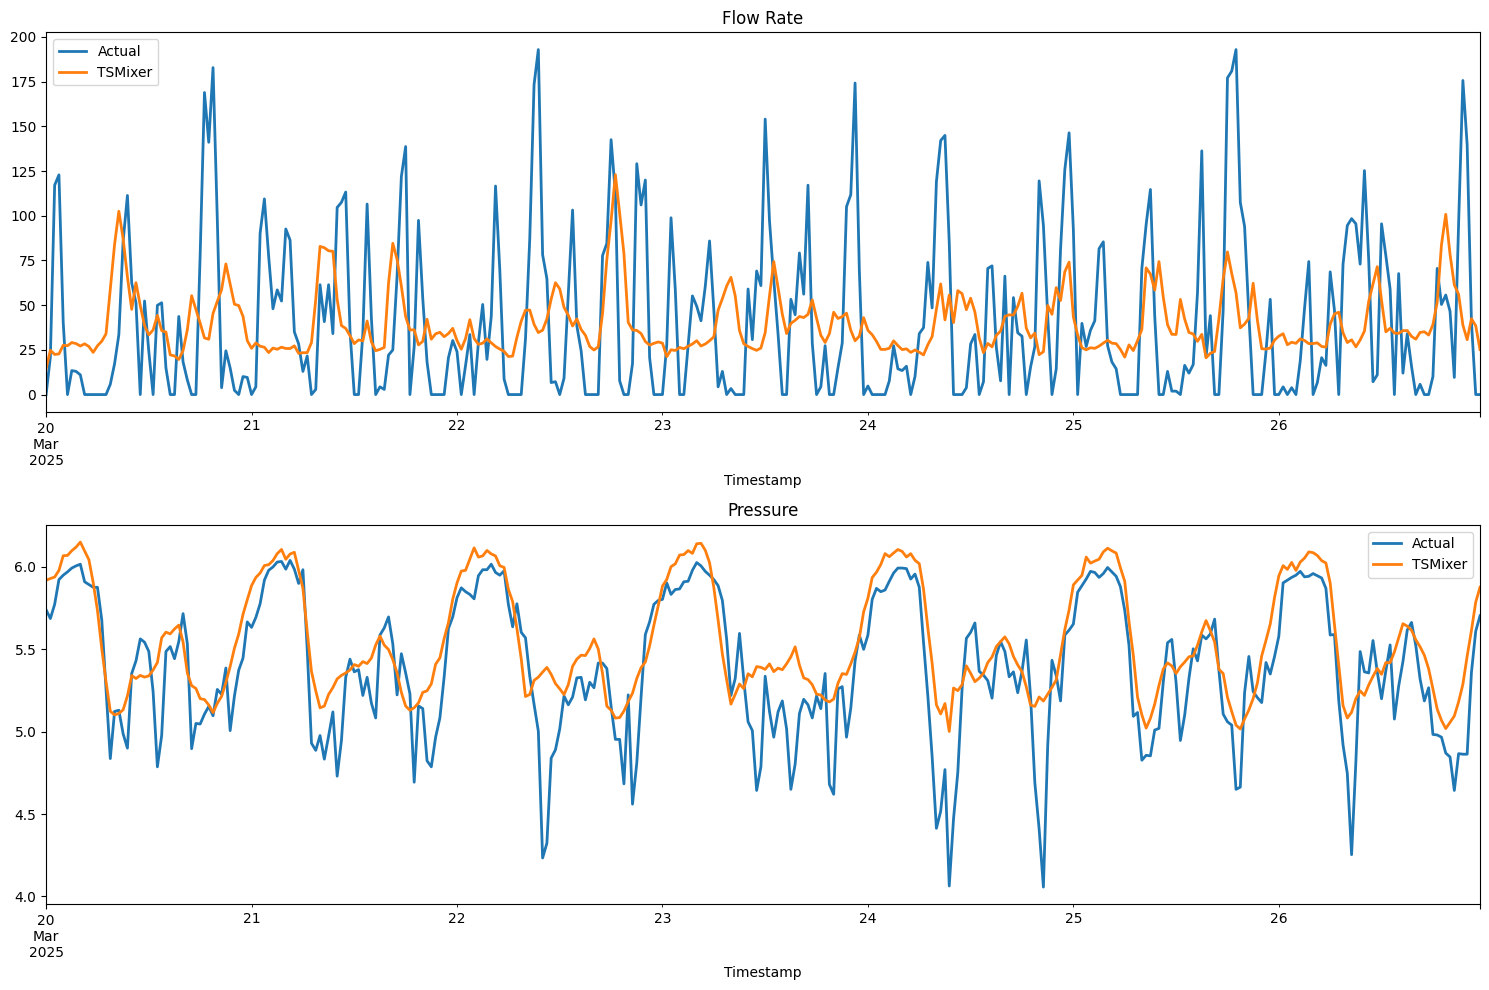

In [4]:
import matplotlib.pyplot as plt

# 6. 예측 및 시각화
pred = model.predict(n=336, series=train)
pred_inv = scaler.inverse_transform(pred)
val_inv = scaler.inverse_transform(val)

# 결과 그래프 출력
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1); val_inv['Flow_Instant'][:336].plot(label='Actual'); pred_inv['Flow_Instant'].plot(label='TSMixer'); plt.title('Flow Rate'); plt.legend()
plt.subplot(2,1,2); val_inv['Pressure'][:336].plot(label='Actual'); pred_inv['Pressure'].plot(label='TSMixer'); plt.title('Pressure'); plt.legend()
plt.tight_layout(); plt.show()
